In [3]:
import numpy as np
from math import pow
import matplotlib.pyplot as plt
plt.style.use('bmh')
import pickle
from pathlib import Path
import os
from utils import *
from tqdm import tqdm

from models import DistanceCellModel, VectorCellModel, NestedModel
OUTPUT_DIR = 'simulation_outputs'


In [2]:
dcm = DistanceCellModel(arena_width=50, dc_res = 0.04)
dcm.scales

[25.0, 35.0, 49.0, 68.6, 96.04, 134.46, 188.24, 263.53, 368.95, 516.53]

In [3]:
arena_width = 50
for model_name in ['nm', 'dcm', 'vcm']:
    
    if model_name == 'dcm':
        model = DistanceCellModel(arena_width=arena_width, dc_res = 0.04)
    elif model_name == 'vcm':
        model = VectorCellModel(arena_width=arena_width)
    elif model_name == 'nm':
        model = NestedModel(arena_width=arena_width)
    print(f"Running {model_name} with scales {model.scales}")

Running nm with scales [100.          66.66666667  44.44444444  29.62962963  19.75308642
  13.16872428   8.77914952   5.85276635   3.90184423   2.60122949]
Running dcm with scales [25.0, 35.0, 49.0, 68.6, 96.04, 134.46, 188.24, 263.53, 368.95, 516.53]
Running vcm with scales [25.0, 35.0, 49.0, 68.6, 96.04, 134.46, 188.24, 263.53, 368.95, 516.53]


### Navigation simulation

In [27]:

def project_onto_axis(pos_xy_mat, l):
    """ 
    Project matrix of 2D positions onto one of three axes (l = 1, 2, 3) that are 60 degrees apart.
    """
    phi_l = -(np.pi/6) + l * (np.pi/3)   # l = 1, 2, 3 -> axes 60 deg apart
    kl = np.array([np.cos(phi_l), np.sin(phi_l)])
    pos_xy_mat = np.array(pos_xy_mat)
    return kl @ pos_xy_mat




In [29]:

'''
    # Project the trajectories onto the hexagonal axes
    if hexagonal_projection:
        x_histories_proj = []
        y_histories_proj = []
        for trial in range(len(x_histories)):
            pos_xy_mat = np.array([x_histories[trial], y_histories[trial]])
            proj_X = project_onto_axis(pos_xy_mat, 1)
            proj_Y = project_onto_axis(pos_xy_mat, 2)
            x_histories_proj.append(proj_X)
            y_histories_proj.append(proj_Y)
        x_histories = x_histories_proj
        y_histories = y_histories_proj
'''

def plot_trajectories(model_name, x_histories, y_histories, arena_width = 50, hexagonal_projection=True):
    long_names = {'nm': 'Nested Model', 'dcm': 'Distance Cell Model', 'vcm': 'Vector Cell Model'}

    n_trials = len(x_histories)
    plt.figure(figsize=(6, 6))

    # Draw disk boundary
    circle = plt.Circle((0, 0), arena_width, color='black', alpha=0.5, linestyle='--', fill=False)
    plt.gca().add_patch(circle)

    success_count = 0
    for trial in range(n_trials):
        last_x = x_histories[trial][-1]
        last_y = y_histories[trial][-1]
        success = np.sqrt(last_x**2 + last_y**2) <= 5
        color = 'blue' if success else 'red'
        success_count += success
        plt.plot(x_histories[trial], y_histories[trial], color=color, markersize=0.001)
  #  plt.xlim(-1, 1)
  #
  #   plt.ylim(-1, 1)
  #  plt.xticks([])
  #  plt.yticks([])
    plt.title(f'{long_names[model_name]}')
    plt.xlabel('x (cm)')
    plt.ylabel('y (cm)')
    plt.axhline(0, color='gray', lw=0.5)
    plt.axvline(0, color='gray', lw=0.5)

    plt.show()
    print(f'Successful trials: {success_count}/{n_trials} ({(success_count/n_trials)*100:.1f}%)')

In [30]:



def navigation_simulation(model_name, arena_width = 50, n_trials=5, step_size = 0.1, convergence_threshold = 0.025, distortion=None, a=0, b=0, hexagonal_projection= True, verbose=False):
    # step_size = 0.1, convergence_threshold = 0.025
    #Initialize corresponding model
    if model_name == 'dcm':
        model = DistanceCellModel(arena_width=arena_width, dc_res = 0.04)
    elif model_name == 'vcm':
        model = VectorCellModel(arena_width=arena_width)
    elif model_name == 'nm':
        model = NestedModel(arena_width=arena_width)
    else:
        raise ValueError("Invalid model name")

    x_histories = []
    y_histories = []

    for i in tqdm(range(n_trials), desc="Simulating trials"):
     
 #       print(f"Trial {i+1}/{n_trials}")
        # Sample a random starting position within the disk
        start_x, start_y = sample_disk_position(disk_radius = arena_width)
        goal_x, goal_y = [0, 0] #sample_disk_position(disk_radius = arena_width)
   #     print(f'ORIGINAL start_pos: ({start_x}, {start_y})')
   #     print(f'ORIGINAL goal_pos: ({goal_x}, {goal_y})')

        if distortion is not None:
         #   print('distortion!!!!!!')
            start_x, start_y = gc_distortion(start_x, start_y, distortion=distortion, a=a, b=b)
            goal_x, goal_y = gc_distortion(goal_x, goal_y, distortion=distortion, a=a, b=b)

        if hexagonal_projection:
            start_x, start_y = project_onto_axis([start_x, start_y], 1), project_onto_axis([start_x, start_y], 2)
            goal_x, goal_y = project_onto_axis([goal_x, goal_y], 1), project_onto_axis([goal_x, goal_y], 2)
            
            
        # Conduct simulations for ten steps
        x_history = [start_x]
        y_history = [start_y]
        converged = False
        step_count = 0
     #   print(f'start_pos: ({start_x}, {start_y})')
        while not converged:

            curr_pop_vec = model.forward(a=[start_x, start_y], b=[goal_x, goal_y])
     #       print('curr_pop_vec', curr_pop_vec)
            curr_pop_vec /= np.linalg.norm(curr_pop_vec) + 1e-10 # Normalize
     #       print('norm curr_pop_vec', curr_pop_vec)

            # Update position based on the population vector
            start_x = x_history[-1] + (curr_pop_vec[0] * step_size)
            start_y = y_history[-1] + (curr_pop_vec[1] * step_size)
            if verbose:
                print(f"Step {step_count}: Position ({start_x:.3f}, {start_y:.3f})")
    
            x_history.append(start_x)
            y_history.append(start_y)


            if distortion is not None:
                start_x, start_y = gc_distortion(x_history[-1], y_history[-1], distortion=distortion, a=a, b=b)
            # Check for convergence only after five steps
            if step_count > 5:
                #print('Check convergence')
                old_x = x_history[-5]
                old_y = y_history[-5]
                distance_moved = np.sqrt((start_x - old_x) ** 2 + (start_y - old_y) ** 2)
                if distance_moved < convergence_threshold or step_count > 2000:
                    converged = True
            step_count += 1
        x_histories.append(x_history)
        y_histories.append(y_history)
    return x_histories, y_histories

def run_load_simulation(model_name, arena_width, n_trials=400, step_size=0.1, distortion = None, a=None, b=None, save_plot=True):
    distortion_text = f'_{distortion}_a-{a}_b-{b}' if distortion is not None else '_undistorted'
    simulation_data_file = Path(OUTPUT_DIR) / f'{model_name}_trials-{n_trials}{distortion_text}.pkl'
    # Run new simulation and save results
    if not os.path.exists(simulation_data_file):
        print('Running new simulation...')
        x_histories, y_histories = navigation_simulation(model_name, 
                                                         arena_width=arena_width, 
                                                         n_trials=n_trials,
                                                         step_size=step_size,
                                                         distortion=distortion, a=a, b=b,
                                                         verbose=False)
        if save_plot:
            with open(simulation_data_file, 'wb') as f:
                pickle.dump((x_histories, y_histories), f) 
                print(f'Saved simulation data to {simulation_data_file}')

    # Otherwise, load already simulated results
    else: 
        print(f'Loading simulation data from {simulation_data_file}')
        x_histories, y_histories = pickle.load(open(simulation_data_file, 'rb'))
    return [x_histories, y_histories]


Running new simulation...


Simulating trials: 100%|██████████| 50/50 [01:43<00:00,  2.06s/it]

Saved simulation data to simulation_outputs/nm_trials-50_undistorted.pkl


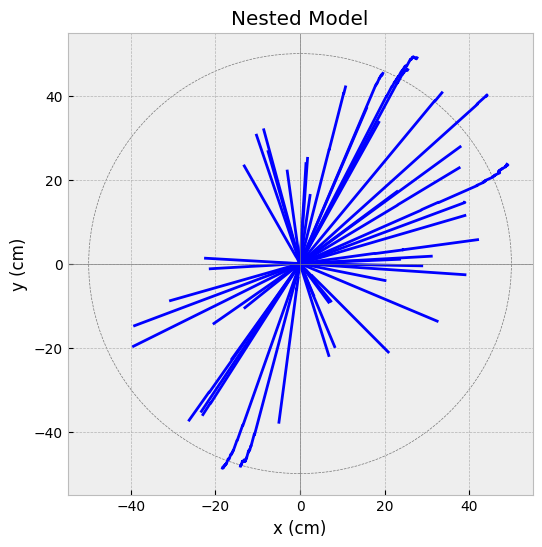

Successful trials: 50/50 (100.0%)


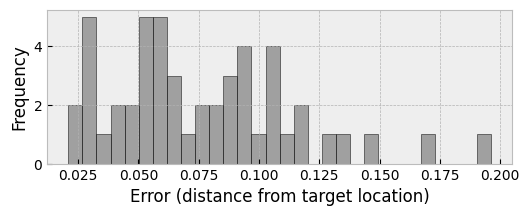

Mean error: 0.08, Median error: 0.07, Std error: 0.04
Running new simulation...


Simulating trials:   2%|▏         | 1/50 [00:00<00:32,  1.51it/s]


KeyboardInterrupt: 

In [32]:
for model_name in ['nm', 'dcm', 'vcm']:
    x_histories, y_histories = run_load_simulation(model_name, 
                                                   arena_width = 50, 
                                                   n_trials=50, 
                                                   step_size=0.1)
    plot_trajectories(model_name, x_histories, y_histories)
    plot_error(x_histories, y_histories)

Loading simulation data from simulation_outputs/nm_trials-400_shear_a-0_b-0.3.pkl
pos_xy_mat shape: (2, 2003), kl shape: (2,)
pos_xy_mat shape: (2, 2003), kl shape: (2,)
pos_xy_mat shape: (2, 68), kl shape: (2,)
pos_xy_mat shape: (2, 68), kl shape: (2,)
pos_xy_mat shape: (2, 2003), kl shape: (2,)
pos_xy_mat shape: (2, 2003), kl shape: (2,)
pos_xy_mat shape: (2, 53), kl shape: (2,)
pos_xy_mat shape: (2, 53), kl shape: (2,)
pos_xy_mat shape: (2, 77), kl shape: (2,)
pos_xy_mat shape: (2, 77), kl shape: (2,)
pos_xy_mat shape: (2, 2003), kl shape: (2,)
pos_xy_mat shape: (2, 2003), kl shape: (2,)
pos_xy_mat shape: (2, 2003), kl shape: (2,)
pos_xy_mat shape: (2, 2003), kl shape: (2,)
pos_xy_mat shape: (2, 31), kl shape: (2,)
pos_xy_mat shape: (2, 31), kl shape: (2,)
pos_xy_mat shape: (2, 2003), kl shape: (2,)
pos_xy_mat shape: (2, 2003), kl shape: (2,)
pos_xy_mat shape: (2, 53), kl shape: (2,)
pos_xy_mat shape: (2, 53), kl shape: (2,)
pos_xy_mat shape: (2, 2003), kl shape: (2,)
pos_xy_mat sha

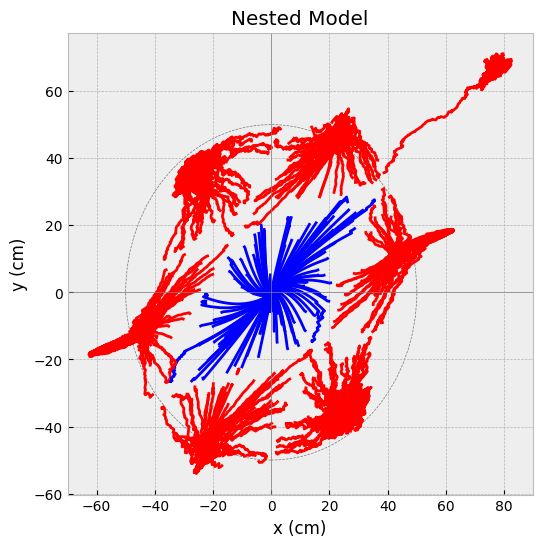

Successful trials: 116/400 (29.0%)


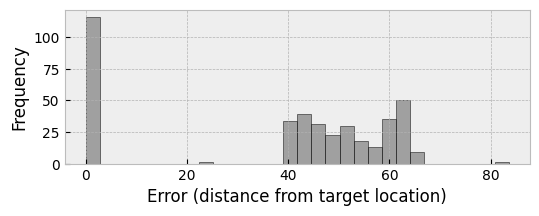

Mean error: 37.06, Median error: 45.54, Std error: 24.63
Loading simulation data from simulation_outputs/dcm_trials-400_shear_a-0_b-0.3.pkl
pos_xy_mat shape: (2, 507), kl shape: (2,)
pos_xy_mat shape: (2, 507), kl shape: (2,)
pos_xy_mat shape: (2, 142), kl shape: (2,)
pos_xy_mat shape: (2, 142), kl shape: (2,)
pos_xy_mat shape: (2, 770), kl shape: (2,)
pos_xy_mat shape: (2, 770), kl shape: (2,)
pos_xy_mat shape: (2, 326), kl shape: (2,)
pos_xy_mat shape: (2, 326), kl shape: (2,)
pos_xy_mat shape: (2, 460), kl shape: (2,)
pos_xy_mat shape: (2, 460), kl shape: (2,)
pos_xy_mat shape: (2, 645), kl shape: (2,)
pos_xy_mat shape: (2, 645), kl shape: (2,)
pos_xy_mat shape: (2, 424), kl shape: (2,)
pos_xy_mat shape: (2, 424), kl shape: (2,)
pos_xy_mat shape: (2, 511), kl shape: (2,)
pos_xy_mat shape: (2, 511), kl shape: (2,)
pos_xy_mat shape: (2, 452), kl shape: (2,)
pos_xy_mat shape: (2, 452), kl shape: (2,)
pos_xy_mat shape: (2, 627), kl shape: (2,)
pos_xy_mat shape: (2, 627), kl shape: (2,)


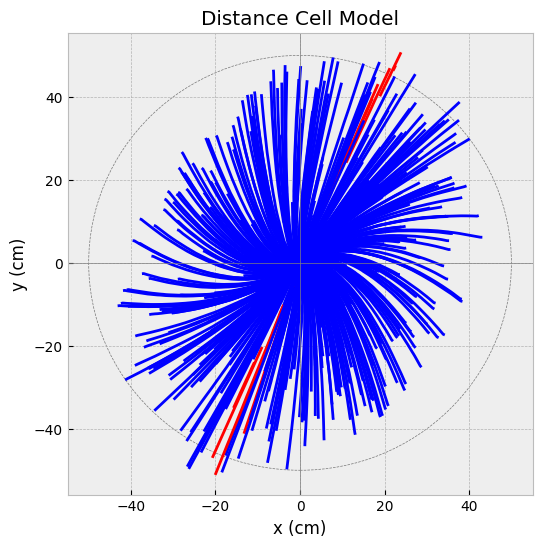

Successful trials: 389/400 (97.2%)


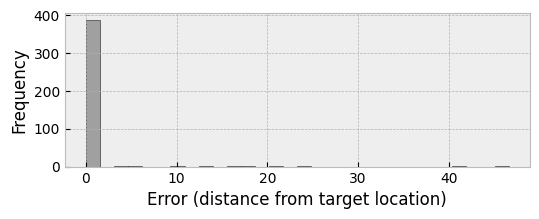

Mean error: 0.86, Median error: 0.25, Std error: 3.90
Loading simulation data from simulation_outputs/vcm_trials-400_shear_a-0_b-0.3.pkl
pos_xy_mat shape: (2, 443), kl shape: (2,)
pos_xy_mat shape: (2, 443), kl shape: (2,)
pos_xy_mat shape: (2, 281), kl shape: (2,)
pos_xy_mat shape: (2, 281), kl shape: (2,)
pos_xy_mat shape: (2, 596), kl shape: (2,)
pos_xy_mat shape: (2, 596), kl shape: (2,)
pos_xy_mat shape: (2, 430), kl shape: (2,)
pos_xy_mat shape: (2, 430), kl shape: (2,)
pos_xy_mat shape: (2, 700), kl shape: (2,)
pos_xy_mat shape: (2, 700), kl shape: (2,)
pos_xy_mat shape: (2, 443), kl shape: (2,)
pos_xy_mat shape: (2, 443), kl shape: (2,)
pos_xy_mat shape: (2, 399), kl shape: (2,)
pos_xy_mat shape: (2, 399), kl shape: (2,)
pos_xy_mat shape: (2, 92), kl shape: (2,)
pos_xy_mat shape: (2, 92), kl shape: (2,)
pos_xy_mat shape: (2, 535), kl shape: (2,)
pos_xy_mat shape: (2, 535), kl shape: (2,)
pos_xy_mat shape: (2, 175), kl shape: (2,)
pos_xy_mat shape: (2, 175), kl shape: (2,)
pos_x

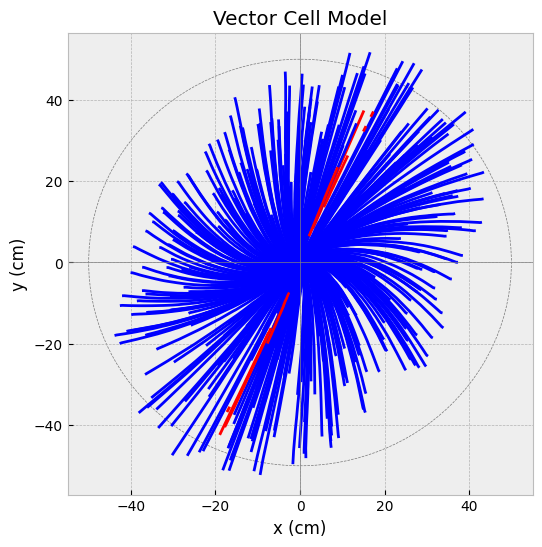

Successful trials: 390/400 (97.5%)


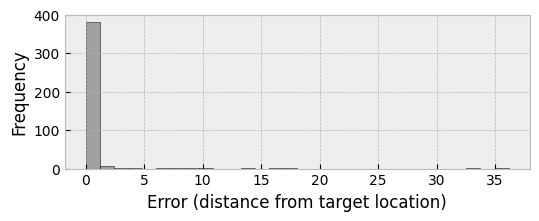

Mean error: 0.79, Median error: 0.25, Std error: 3.38


In [23]:
for model_name in ['nm', 'dcm', 'vcm']:
    x_histories, y_histories = run_load_simulation(model_name, 
                                                   arena_width = 50, 
                                                   n_trials=400, 
                                                   step_size=0.1,
                                                   distortion='shear', a=0, b=0.3)
    plot_trajectories(model_name, x_histories, y_histories)
    plot_error(x_histories, y_histories)


Loading simulation data from simulation_outputs/dcm_trials-400_stretch_a-1_b-0.67.pkl
pos_xy_mat shape: (2, 205), kl shape: (2,)
pos_xy_mat shape: (2, 205), kl shape: (2,)
pos_xy_mat shape: (2, 580), kl shape: (2,)
pos_xy_mat shape: (2, 580), kl shape: (2,)
pos_xy_mat shape: (2, 553), kl shape: (2,)
pos_xy_mat shape: (2, 553), kl shape: (2,)
pos_xy_mat shape: (2, 599), kl shape: (2,)
pos_xy_mat shape: (2, 599), kl shape: (2,)
pos_xy_mat shape: (2, 28), kl shape: (2,)
pos_xy_mat shape: (2, 28), kl shape: (2,)
pos_xy_mat shape: (2, 521), kl shape: (2,)
pos_xy_mat shape: (2, 521), kl shape: (2,)
pos_xy_mat shape: (2, 720), kl shape: (2,)
pos_xy_mat shape: (2, 720), kl shape: (2,)
pos_xy_mat shape: (2, 709), kl shape: (2,)
pos_xy_mat shape: (2, 709), kl shape: (2,)
pos_xy_mat shape: (2, 581), kl shape: (2,)
pos_xy_mat shape: (2, 581), kl shape: (2,)
pos_xy_mat shape: (2, 481), kl shape: (2,)
pos_xy_mat shape: (2, 481), kl shape: (2,)
pos_xy_mat shape: (2, 359), kl shape: (2,)
pos_xy_mat sh

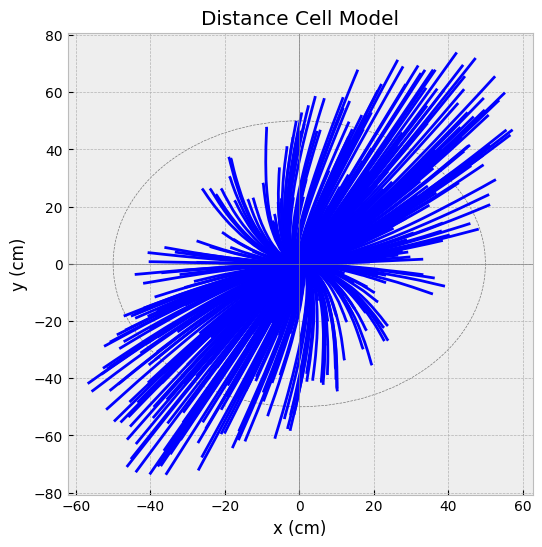

Successful trials: 400/400 (100.0%)


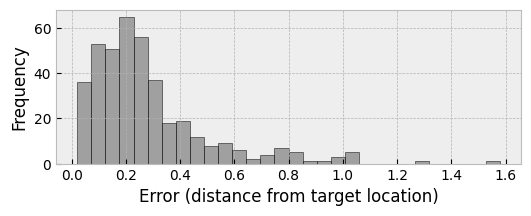

Mean error: 0.28, Median error: 0.23, Std error: 0.22
Loading simulation data from simulation_outputs/vcm_trials-400_stretch_a-1_b-0.67.pkl
pos_xy_mat shape: (2, 270), kl shape: (2,)
pos_xy_mat shape: (2, 270), kl shape: (2,)
pos_xy_mat shape: (2, 1360), kl shape: (2,)
pos_xy_mat shape: (2, 1360), kl shape: (2,)
pos_xy_mat shape: (2, 1196), kl shape: (2,)
pos_xy_mat shape: (2, 1196), kl shape: (2,)
pos_xy_mat shape: (2, 549), kl shape: (2,)
pos_xy_mat shape: (2, 549), kl shape: (2,)
pos_xy_mat shape: (2, 73), kl shape: (2,)
pos_xy_mat shape: (2, 73), kl shape: (2,)
pos_xy_mat shape: (2, 162), kl shape: (2,)
pos_xy_mat shape: (2, 162), kl shape: (2,)
pos_xy_mat shape: (2, 463), kl shape: (2,)
pos_xy_mat shape: (2, 463), kl shape: (2,)
pos_xy_mat shape: (2, 631), kl shape: (2,)
pos_xy_mat shape: (2, 631), kl shape: (2,)
pos_xy_mat shape: (2, 489), kl shape: (2,)
pos_xy_mat shape: (2, 489), kl shape: (2,)
pos_xy_mat shape: (2, 1078), kl shape: (2,)
pos_xy_mat shape: (2, 1078), kl shape: (

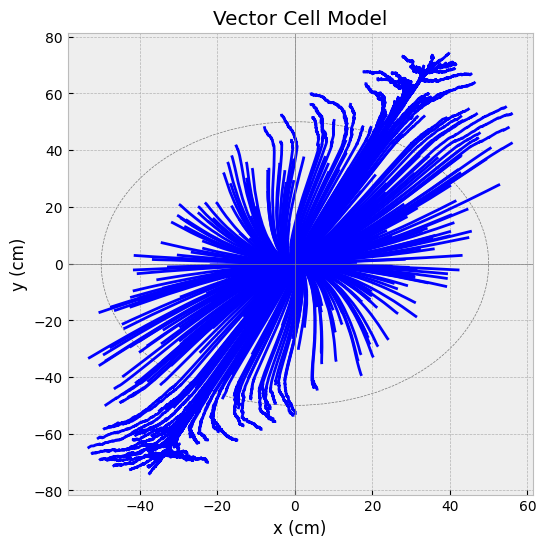

Successful trials: 400/400 (100.0%)


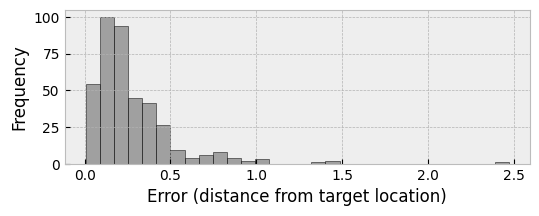

Mean error: 0.28, Median error: 0.21, Std error: 0.24
Loading simulation data from simulation_outputs/nm_trials-400_stretch_a-1_b-0.67.pkl
pos_xy_mat shape: (2, 2003), kl shape: (2,)
pos_xy_mat shape: (2, 2003), kl shape: (2,)
pos_xy_mat shape: (2, 2003), kl shape: (2,)
pos_xy_mat shape: (2, 2003), kl shape: (2,)
pos_xy_mat shape: (2, 2003), kl shape: (2,)
pos_xy_mat shape: (2, 2003), kl shape: (2,)
pos_xy_mat shape: (2, 2003), kl shape: (2,)
pos_xy_mat shape: (2, 2003), kl shape: (2,)
pos_xy_mat shape: (2, 72), kl shape: (2,)
pos_xy_mat shape: (2, 72), kl shape: (2,)
pos_xy_mat shape: (2, 122), kl shape: (2,)
pos_xy_mat shape: (2, 122), kl shape: (2,)
pos_xy_mat shape: (2, 2003), kl shape: (2,)
pos_xy_mat shape: (2, 2003), kl shape: (2,)
pos_xy_mat shape: (2, 2003), kl shape: (2,)
pos_xy_mat shape: (2, 2003), kl shape: (2,)
pos_xy_mat shape: (2, 2003), kl shape: (2,)
pos_xy_mat shape: (2, 2003), kl shape: (2,)
pos_xy_mat shape: (2, 2003), kl shape: (2,)
pos_xy_mat shape: (2, 2003), kl

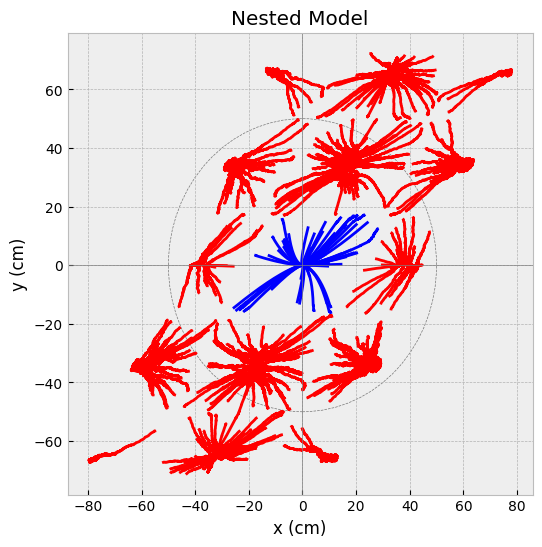

Successful trials: 54/400 (13.5%)


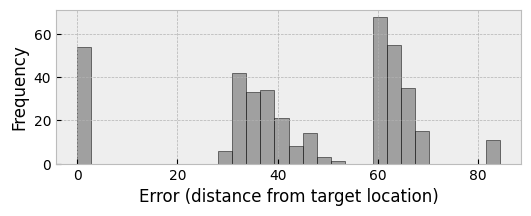

Mean error: 44.78, Median error: 45.42, Std error: 22.21


In [24]:
for model_name in ['dcm', 'vcm', 'nm']:
    x_histories, y_histories = run_load_simulation(model_name, 
                                                   arena_width = 50, 
                                                   n_trials=400, 
                                                   step_size=0.1,
                                                   distortion='stretch', a=1, b=0.67)
    plot_trajectories(model_name, x_histories, y_histories)
    plot_error(x_histories, y_histories)

Running new simulation...


Simulating trials: 100%|██████████| 400/400 [06:35<00:00,  1.01it/s]


Saved simulation data to simulation_outputs/dcm_trials-400_shear_a-0_b-0.3.pkl


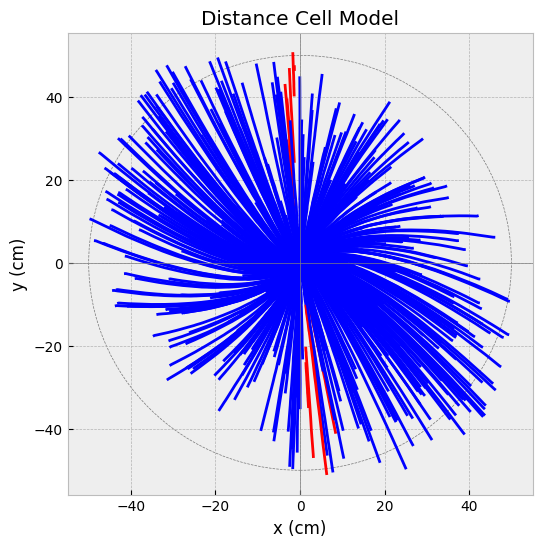

Successful trials: 389/400 (97.2%)


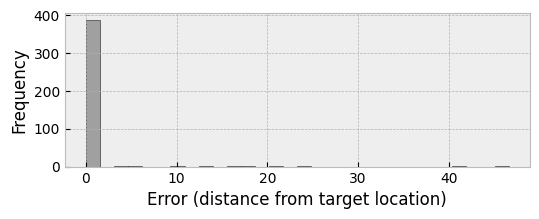

Mean error: 0.86, Median error: 0.25, Std error: 3.90


In [103]:
for model_name in ['dcm']:
    x_histories, y_histories = run_load_simulation(model_name, 
                                                   arena_width = 50, 
                                                   n_trials=400, 
                                                   step_size=0.1,
                                                   distortion='shear', a=0, b=0.3)
    plot_trajectories(model_name, x_histories, y_histories)
    plot_error(x_histories, y_histories)

### Translation vector simulation

In [4]:
def translation_vec_simulation(model_name, N=1000, arena_width = 50, gc_distortion=None, plot_results=True):

    #Initialize corresponding model
    if model_name == 'dcm':
        model = DistanceCellModel(arena_width=arena_width, dc_res = 0.04)
        title = 'DistanceCellModel'
    elif model_name == 'vcm':
        model = VectorCellModel(arena_width=arena_width)
        title = 'VectorCellModel'
    elif model_name == 'nm':
        model = NestedModel(arena_width=arena_width)
        title = 'NestedModel'
    else:
        raise ValueError("Invalid model name")

    # Generate random starting positions and target positions
    a_s = [(np.random.rand(N) * arena_width * 2) - arena_width for _ in range(2)]
    b_s = [np.zeros(N) for _ in range(2)]  # Target positions are all zeros [(np.random.rand(N) * arena_width * 2) - arena_width for _ in range(2)]
  #  b_s = [(np.random.rand(N) * arena_width * 2) - arena_width for _ in range(2)]
    # Apply distortion if provided
    if gc_distortion is None or gc_distortion.distortion is None:
        print('No distortion applied.')
        a_s_dist = a_s
        b_s_dist = b_s
    else: 
        print(f'Applying {gc_distortion.distortion} distortion with a={gc_distortion.a}, b={gc_distortion.b}')
        a_s_dist = gc_distortion.apply(a_s[0], a_s[1])
        b_s_dist = gc_distortion.apply(b_s[0], b_s[1])

    # Generate translation vectors and decode them using the model
    true_trans_vecs = np.array([(b_s[0] - a_s[0]), (b_s[1] - a_s[1])])
    pred_trans_vecs = []
    for i in range(N):
        
        curr_pop_vec = model.forward(a=[a_s_dist[0][i], a_s_dist[1][i]], b=[b_s_dist[0][i], b_s_dist[1][i]])
        pred_trans_vecs.append(curr_pop_vec)
    #    print(f'b_s[0][{i}]:', b_s[0][i])
    #    true_distance = [b_s[0][i] - a_s[0][i], b_s[1][i] - a_s[1][i] ]
    #    print(f'For trial {i+1}/{N}, true distance: ({true_distance[0]}, {true_distance[1]}), decoded b_hat: ({curr_pop_vec[0]}, {curr_pop_vec[1]})')
    pred_trans_vecs = np.array(pred_trans_vecs).T




    # Plot two plots for x and y
    if plot_results:
        plt.subplots(1, 2, figsize=(12, 5))
        for i in range(2):
            plt.subplot(1, 2, i+1)
            plt.scatter(true_trans_vecs[i] / 100, pred_trans_vecs[i] / 100, color='black', s=1)
            plt.xlabel('True Translation Vector (m)')
            plt.ylabel('Decoded Translation Vector (m)')
            curr_axis = 'x' if i == 0 else 'y'
            plt.title(f'{curr_axis}-axis')
        plt.suptitle(title)
        plt.show()

    return a_s, b_s, pred_trans_vecs

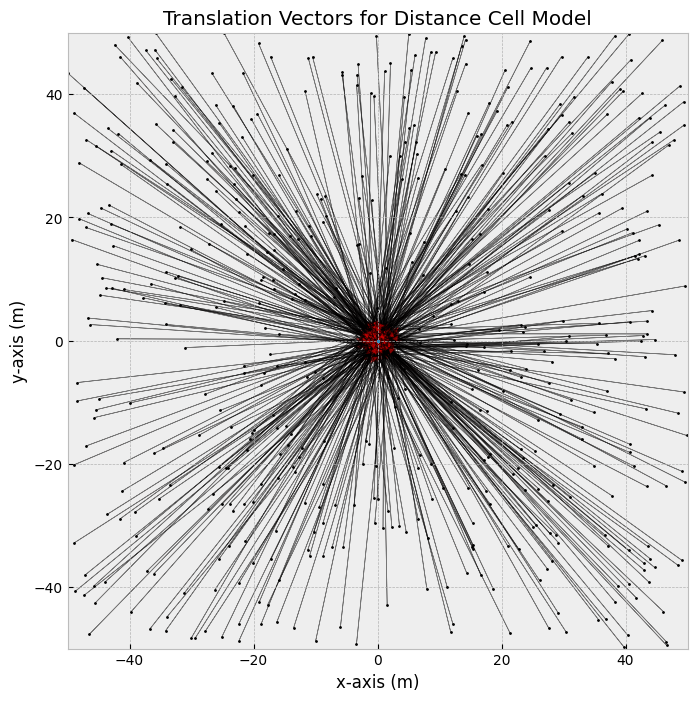

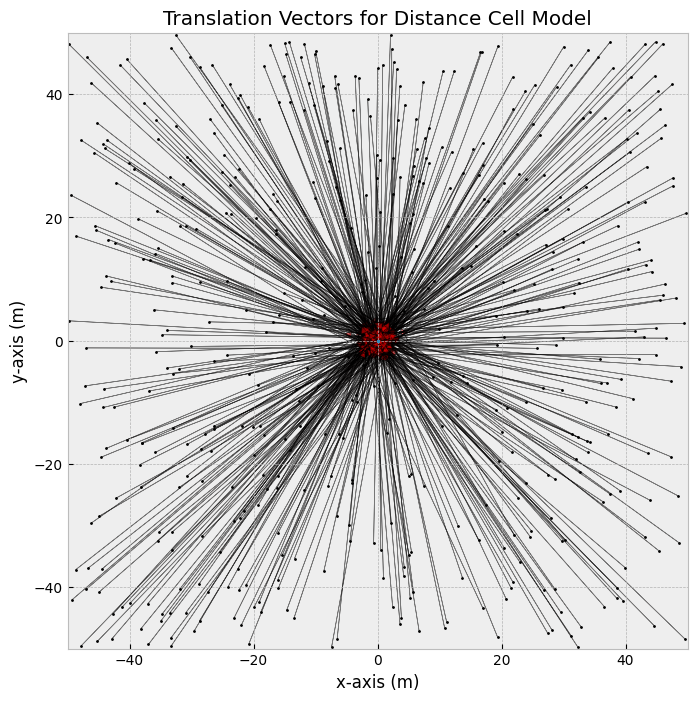

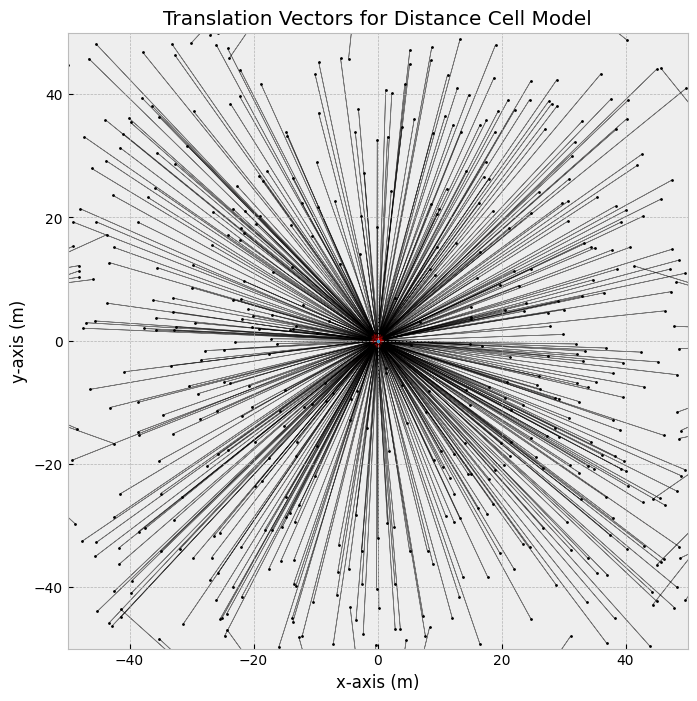

In [7]:


def plot_trans_vec_results(trans_vec_results, arena_width=50):
    model_names = trans_vec_results.keys()
    for model_name in model_names:
        a_s = trans_vec_results[model_name][0]
        b_s = trans_vec_results[model_name][1]
        pred_trans_vecs = trans_vec_results[model_name][2]
        plt.figure(figsize=(8, 8))
        plt.plot(a_s[0], a_s[1], 'o', color='black', label='Start Position', markersize=1)
        plt.plot(b_s[0], b_s[1], 'o', label='End Position', markersize=1)
        for i in range(pred_trans_vecs.shape[1]):
            plt.arrow(a_s[0][i], a_s[1][i], pred_trans_vecs[0][i], pred_trans_vecs[1][i], head_width=1, head_length=1, fc='red', ec='black', alpha=0.5)
        plt.xlabel('x-axis (m)')
        plt.ylabel('y-axis (m)')
        plt.xlim(-arena_width, arena_width)
        plt.ylim(-arena_width, arena_width)
        plt.title('Translation Vectors for Distance Cell Model')
        plt.show()
plot_trans_vec_results(trans_vec_results)

Applying shear distortion with a=0.3, b=0.3


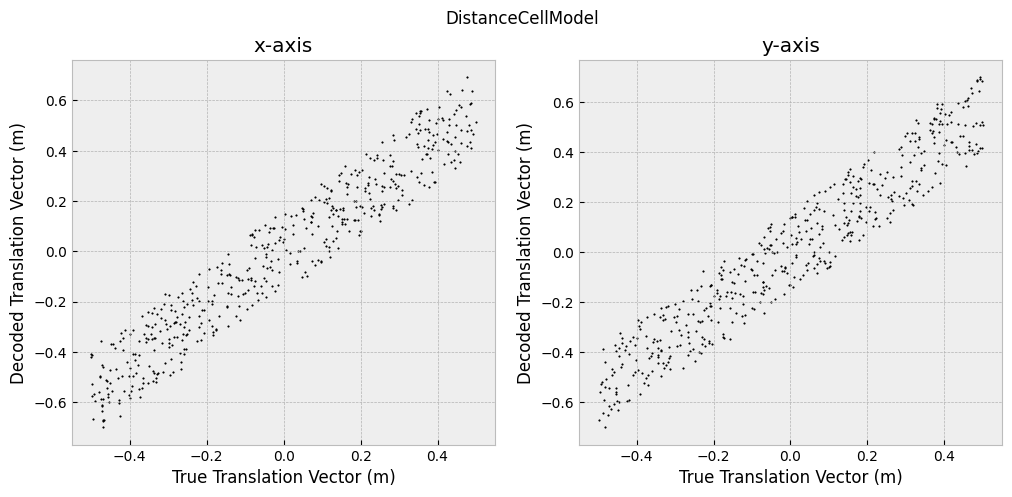

Applying shear distortion with a=0.3, b=0.3


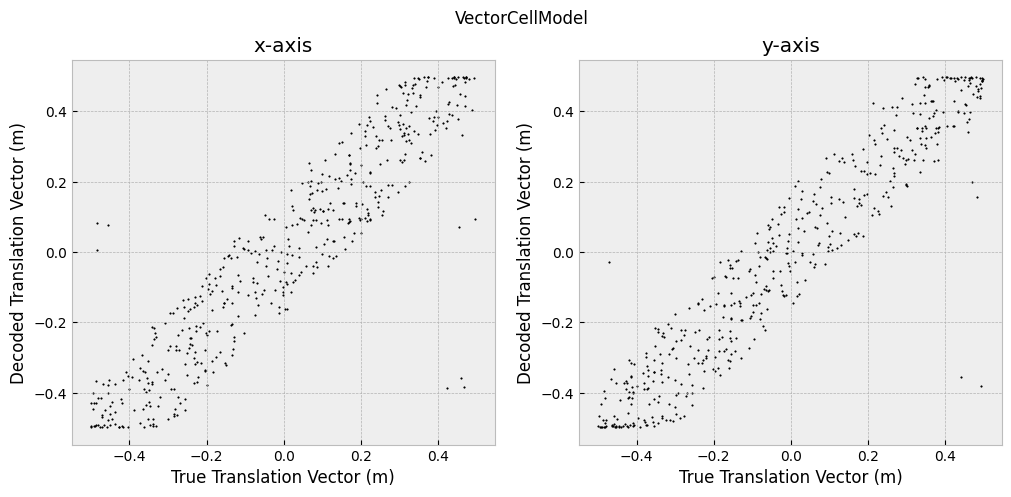

Applying shear distortion with a=0.3, b=0.3


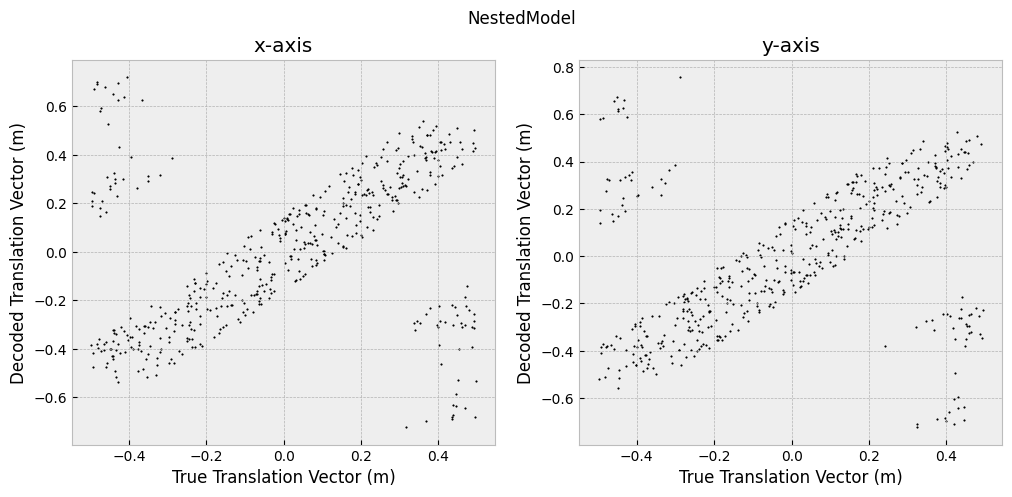

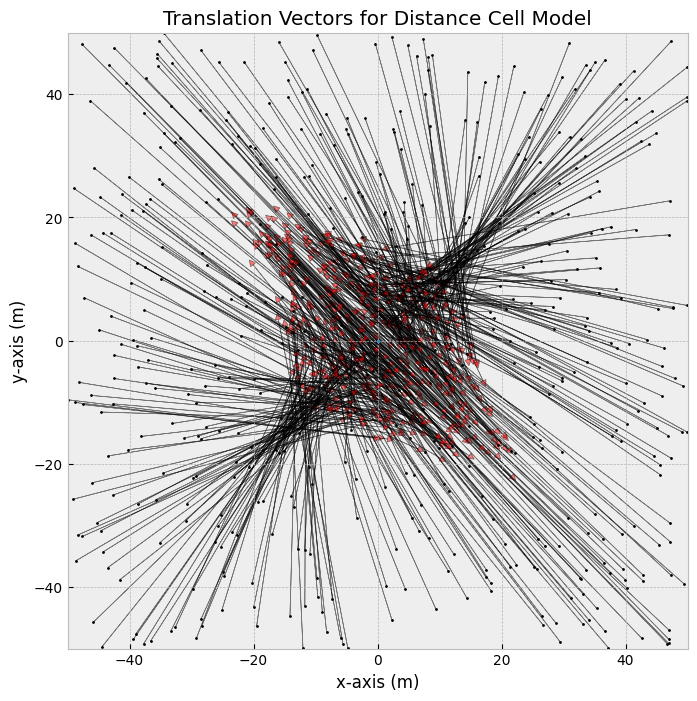

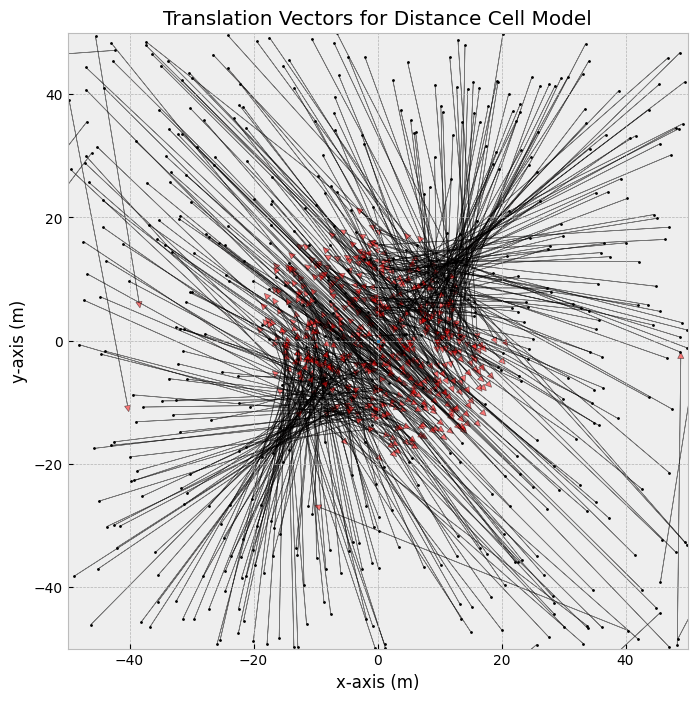

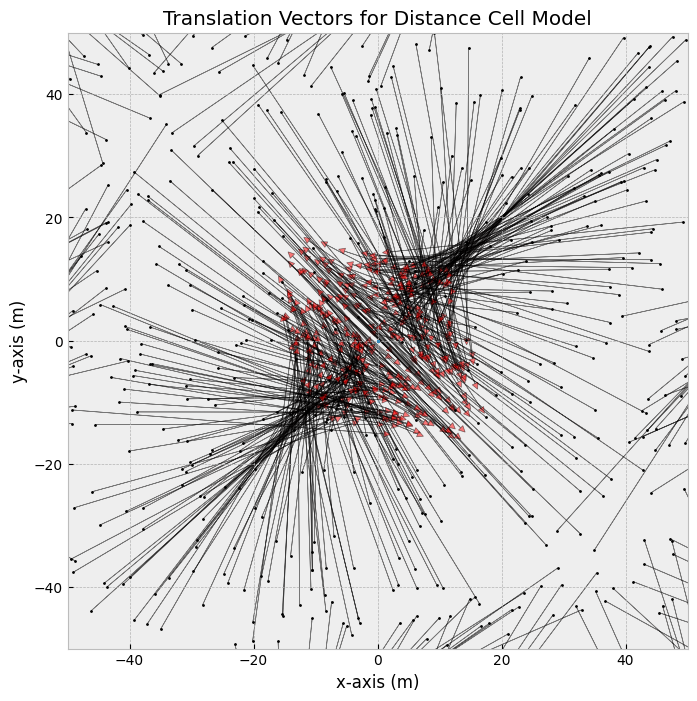

In [8]:
trans_vec_results = {}
for model_name in ['dcm', 'vcm', 'nm']:
    a_s, b_s, pred_trans_vecs = translation_vec_simulation(model_name, 
                                                                  N=500, 
                                                                  arena_width = 50, 
                                                                  gc_distortion=GC_Distortion(distortion='shear', a=0.3, b=0.3))
    trans_vec_results[model_name] = (a_s, b_s, pred_trans_vecs)
plot_trans_vec_results(trans_vec_results)

### COMBINATORIAL (Bush et al., 2015)

In [2]:
nm = NestedModel()
print(nm.forward(a=[250, 250], b=[258, 258]))
print(nm.forward(a=[-19, 1], b=[0, 0]))
print(nm.scales)


(-34.236222440563054, -54.79538506659507)
(18.70964991546043, -0.9138710114200769)
[100.          66.66666667  44.44444444  29.62962963  19.75308642
  13.16872428   8.77914952   5.85276635   3.90184423   2.60122949]


In [3]:
nm = NestedModel()
print(nm.forward(a=[250, 250], b=[258, 258]))
print(nm.forward(a=[-19, 1], b=[0, 0]))
print(nm.scales)


(-33.99893737452001, -65.14446864694553)
(19.135270365284207, -1.0637288282421462)
[100.          66.66666667  44.44444444  29.62962963  19.75308642
  13.16872428   8.77914952   5.85276635   3.90184423   2.60122949]
